In [2]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import os
import glob

from config import config
from utils import (
    refine_mask_small_components,
)



================ Image 00 ================

Mask distribution:
Sand: 65,533
Cement: 3

Confidence summary:
min=66, max=100
Sand: mean=99.75, >=80 => 65033/65533 (99.24%)
Cement: mean=69.00, >=80 => 0/3 (0.00%)

Changed pixels: 0


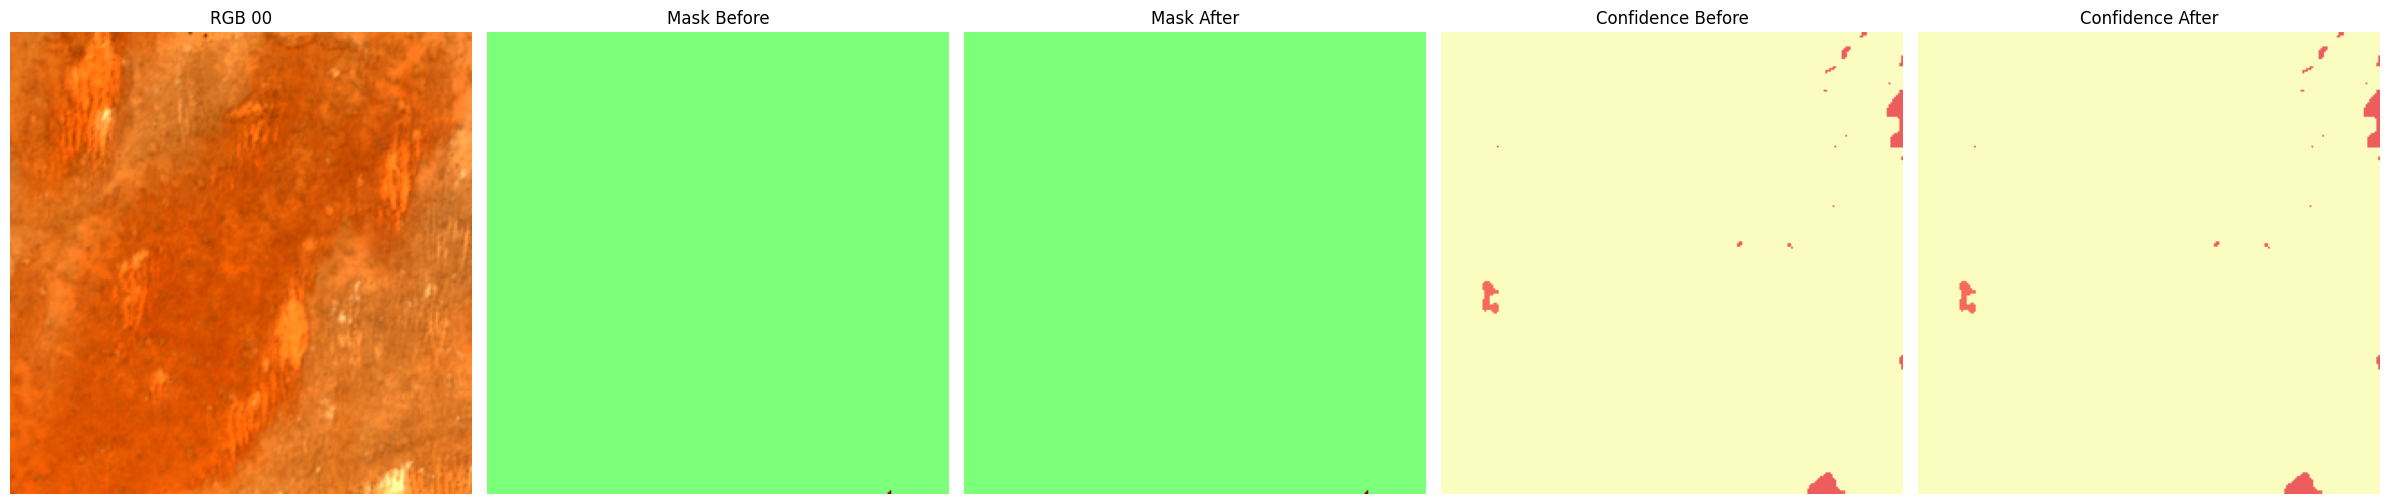

In [3]:
IMG_DIR = "./data/imgs"
MASK_DIR = "./data/masks"

img_paths = sorted(glob.glob(os.path.join(IMG_DIR, "img_*.tif")))

for img_path in img_paths:
    # extract image id
    img_id = os.path.basename(img_path).split("_")[1].split(".")[0]
    mask_path = os.path.join(MASK_DIR, f"mask_{img_id}.tif")

    if not os.path.exists(mask_path):
        print(f"⚠️ Missing mask for {img_path}, skipping...")
        continue

    print(f"\n================ Image {img_id} ================\n")

    # -------- Load Image --------
    with rasterio.open(img_path) as src:
        img = src.read()

    rgb = np.stack([img[3], img[2], img[1]], axis=-1).astype(np.float32)

    p2, p98 = np.percentile(rgb, (2, 98))
    rgb = np.clip((rgb - p2) / (p98 - p2 + 1e-6), 0, 1)

    # -------- Load Mask --------
    with rasterio.open(mask_path) as src:
        mask = src.read(1)
        confidence = src.read(2)

    # -------- Refinement --------
    refined_mask, refined_confidence, refine_flag = refine_mask_small_components(
        mask,
        confidence=confidence,
        return_details=True,
        **config.REFINE_KWARGS,
    )

    # -------- Stats --------
    mask_values, mask_counts = np.unique(mask, return_counts=True)

    print("Mask distribution:")
    for value, count in zip(mask_values, mask_counts):
        class_name = config.CLASS_NAMES.get(int(value), "Unknown")
        print(f"{class_name}: {count:,}")

    print("\nConfidence summary:")
    print(f"min={int(confidence.min())}, max={int(confidence.max())}")

    for value in mask_values:
        class_name = config.CLASS_NAMES.get(int(value), "Unknown")
        class_mask = mask == value
        class_conf = confidence[class_mask]

        total = class_conf.size
        above_thr = int((class_conf >= config.REFINE_KWARGS["confidence_cap"]).sum())
        pct = 100.0 * above_thr / total if total > 0 else 0.0
        mean_conf = float(class_conf.mean()) if total > 0 else 0.0

        print(
            f"{class_name}: mean={mean_conf:.2f}, "
            f">={config.REFINE_KWARGS['confidence_cap']} => {above_thr}/{total} ({pct:.2f}%)"
        )

    changed_pixels = int(refine_flag.sum())
    print(f"\nChanged pixels: {changed_pixels:,}")

    # -------- Visualization --------
    plt.figure(figsize=(24, 5))

    plt.subplot(1, 5, 1)
    plt.title(f"RGB {img_id}")
    plt.imshow(rgb)
    plt.axis("off")

    plt.subplot(1, 5, 2)
    plt.title("Mask Before")
    plt.imshow(mask, cmap="jet", vmin=0, vmax=4)
    plt.axis("off")

    plt.subplot(1, 5, 3)
    plt.title("Mask After")
    plt.imshow(refined_mask, cmap="jet", vmin=0, vmax=4)
    plt.axis("off")

    plt.subplot(1, 5, 4)
    plt.title("Confidence Before")
    plt.imshow(confidence, cmap="magma", vmin=0, vmax=100)
    plt.axis("off")

    plt.subplot(1, 5, 5)
    plt.title("Confidence After")
    plt.imshow(refined_confidence, cmap="magma", vmin=0, vmax=100)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    break